In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import os
import PIL
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib

2026-03-18 16:02:43.034706: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773849763.443415      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773849763.558833      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773849764.609313      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773849764.609360      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773849764.609364      55 computation_placer.cc:177] computation placer alr

## Images Loading

In [5]:
dataset_location = pathlib.Path("/kaggle/input/datasets/sallyibrahim/skin-cancer-isic-2019-2020-malignant-or-benign/skin_dataset_resized")
dataset_location

PosixPath('/kaggle/input/datasets/sallyibrahim/skin-cancer-isic-2019-2020-malignant-or-benign/skin_dataset_resized')

In [6]:
image_count = len(list(dataset_location.glob("*/*/*.jpg")))
image_count

11400

In [7]:
cancer_image_dict = {
    "benign" : list(dataset_location.glob("*/benign/*")),
    "malignant" : list(dataset_location.glob("*/malignant/*"))
}

In [8]:
cancer_label_dict = {
    "benign" : 0,
    "malignant" : 1
}

In [9]:
x, y = [], []

for lesion_type, images in cancer_image_dict.items():
    for image in images:
        img = cv2.imread(image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resized_img = cv2.resize(img, (128,128))
        x.append(resized_img)
        y.append(cancer_label_dict[lesion_type])

In [10]:
def show_images(tag):
    plt.imshow(x[tag])
    print(y[tag])

0


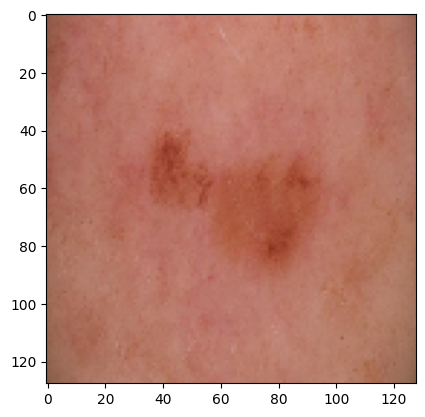

In [11]:
show_images(500)

In [12]:
x = np.array(x)
y = np.array(y)

In [13]:
y.shape

(11400,)

In [14]:
print("0 count:", np.sum(y == 0))
print("1 count:", np.sum(y == 1))

0 count: 6300
1 count: 5100


In [67]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, stratify=y)

In [62]:
x_train.shape

(10260, 128, 128, 3)

In [63]:
x_test.shape

(1140, 128, 128, 3)

In [69]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [70]:
x_train_scaled[1]

array([[[0.18039216, 0.1254902 , 0.09019608],
        [0.2       , 0.14509804, 0.10980392],
        [0.19607843, 0.14117647, 0.10588235],
        ...,
        [0.31764706, 0.23921569, 0.19607843],
        [0.29411765, 0.22352941, 0.17647059],
        [0.2745098 , 0.20392157, 0.15686275]],

       [[0.18431373, 0.1254902 , 0.09803922],
        [0.19215686, 0.13333333, 0.10588235],
        [0.19607843, 0.1372549 , 0.10980392],
        ...,
        [0.33333333, 0.25490196, 0.21176471],
        [0.31372549, 0.24313725, 0.19607843],
        [0.29019608, 0.21960784, 0.17254902]],

       [[0.18431373, 0.1254902 , 0.09803922],
        [0.19607843, 0.1372549 , 0.10980392],
        [0.18823529, 0.12941176, 0.10196078],
        ...,
        [0.35686275, 0.27058824, 0.22745098],
        [0.32156863, 0.24313725, 0.2       ],
        [0.30980392, 0.23137255, 0.18823529]],

       ...,

       [[0.16470588, 0.11764706, 0.11764706],
        [0.15686275, 0.11372549, 0.10588235],
        [0.1372549 , 0

In [71]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [72]:
class_weight = {
    0: 0.90,
    1: 1.12
}

In [73]:


model = Sequential([
    
    tf.keras.Input(shape=(128,128,3)),
    data_augmentation,
    
    layers.Conv2D(32,3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    # layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
    
])


model.compile(
    optimizer = "adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
    
)


In [113]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,571,589 (25.07 MB)

 Trainable params: 2,190,529 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,381,060 (16.71 MB)

In [75]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train_scaled, 
    y_train,
    epochs=30,
    validation_split=0.2,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6833 - loss: 0.5791 - val_accuracy: 0.8484 - val_loss: 0.3802
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8244 - loss: 0.4008 - val_accuracy: 0.8377 - val_loss: 0.3885
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8395 - loss: 0.3587 - val_accuracy: 0.8621 - val_loss: 0.3220
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8485 - loss: 0.3533 - val_accuracy: 0.8782 - val_loss: 0.3203
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8650 - loss: 0.3306 - val_accuracy: 0.8689 - val_loss: 0.3016
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8666 - loss: 0.3231 - val_accuracy: 0.8616 - val_loss: 0.3115
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8723 - loss: 0.3127 - val_accuracy: 0.8796 - val_loss: 0.2789
Epoch 8/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8745 - loss: 0.3103 - val_accu

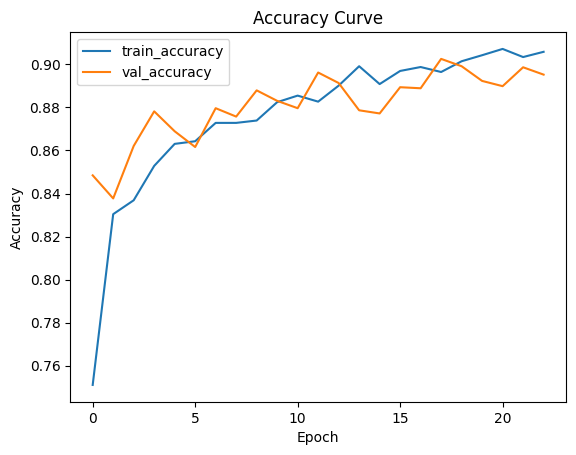

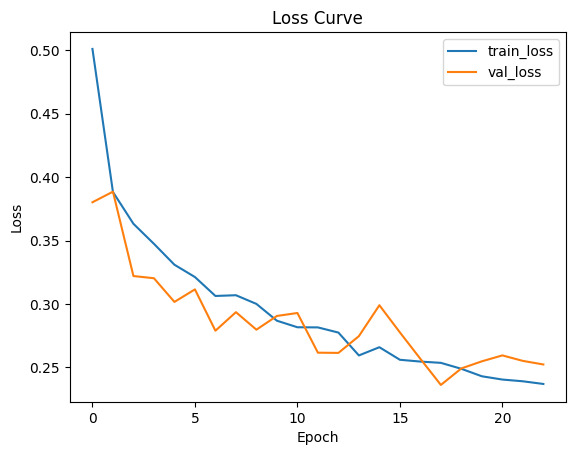

In [76]:
# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [24]:
# model.fit(x_train_scaled,y_train,epochs=15, class_weight=class_weight)

In [77]:
model.evaluate(x_test_scaled,y_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9158 - loss: 0.2257


[0.23185786604881287, 0.9105263352394104]

In [86]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_prob = model.predict(x_test_scaled)

# y_pred = np.round(y_pred)
y_pred = (y_prob > 0.4).astype(int)


print(classification_report(y_test,y_pred))

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       630
           1       0.86      0.92      0.89       510

    accuracy                           0.90      1140
   macro avg       0.90      0.90      0.90      1140
weighted avg       0.90      0.90      0.90      1140



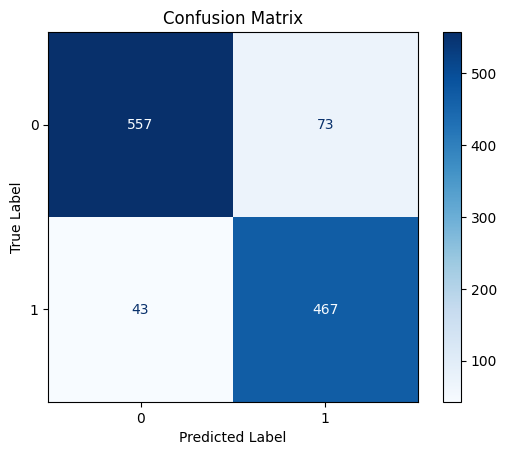

In [87]:
cm = confusion_matrix(y_test,y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [88]:
 model.save("ARSkinCD_version_2.keras")

In [89]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    img = np.array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    
    pred = model.predict(img)
    prob = pred[0][0]

    if pred[0][0] > 0.4:
        print("malignant")
        print("Cancerous Probability:", prob)
    else:
        print("benign")
        print("Cancerous Probability:", prob)

In [90]:
predict_image("/kaggle/input/datasets/anikpaul007/benign2/benign-skin-tumours-lumps-bumps.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
benign
Cancerous Probability: 0.13651268


In [91]:
# model.save("/kaggle/working/ASkinCD.keras")

## Loading the model and testing

In [92]:
loaded_model = tf.keras.models.load_model("/kaggle/working/ARSkinCD_version_2.keras")

In [93]:
loaded_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,571,589 (25.07 MB)

 Trainable params: 2,190,529 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,381,060 (16.71 MB)

In [96]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    img = np.array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    
    pred = loaded_model.predict(img)
    prob = pred[0][0]

    if pred[0][0] > 0.4:
        print("malignant")
        print("Cancerous Probability:", prob)
    else:
        print("benign")
        print("Cancerous Probability:", prob)

    return img, prob

In [97]:
predict_image("/kaggle/input/datasets/anikpaul007/benign2/benign-skin-tumours-lumps-bumps.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
benign
Cancerous Probability: 0.13651268


(array([[[[0.60392157, 0.36470588, 0.11764706],
          [0.57647059, 0.32941176, 0.05490196],
          [0.58823529, 0.36078431, 0.13333333],
          ...,
          [0.91764706, 0.75686275, 0.62745098],
          [0.90980392, 0.75294118, 0.64313725],
          [0.91372549, 0.73333333, 0.6       ]],
 
         [[0.58039216, 0.34117647, 0.08627451],
          [0.58039216, 0.3372549 , 0.09803922],
          [0.61960784, 0.39607843, 0.21568627],
          ...,
          [0.90588235, 0.72156863, 0.61960784],
          [0.92941176, 0.74117647, 0.63137255],
          [0.90980392, 0.72156863, 0.58431373]],
 
         [[0.56078431, 0.3254902 , 0.05098039],
          [0.59607843, 0.36470588, 0.15294118],
          [0.6627451 , 0.45490196, 0.29019608],
          ...,
          [0.94509804, 0.78431373, 0.69019608],
          [0.94509804, 0.76078431, 0.65490196],
          [0.90196078, 0.72156863, 0.58823529]],
 
         ...,
 
         [[0.85098039, 0.70588235, 0.59215686],
          [0.87058

# XAI

In [98]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    img = np.array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    
    pred = clean_model.predict(img)
    prob = pred[0][0]

    if pred[0][0] > 0.4:
        print("malignant")
        print("Cancerous Probability:", prob)
    else:
        print("benign")
        print("Cancerous Probability:", prob)

    return img, prob

In [99]:
inputs = tf.keras.Input(shape=(128,128,3))

x = inputs

for layer in model.layers:
    if "random" in layer.name or "sequential" in layer.name:
        continue
    x = layer(x)

clean_model = tf.keras.Model(inputs, x)

In [100]:
clean_model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,529 (8.36 MB)

 Trainable params: 2,190,529 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
clean_model(tf.zeros((1,128,128,3)))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.48687822]], dtype=float32)>

In [102]:

def gradcam(model, img_array, last_conv_layer='conv2d_5'):
    img_tensor = tf.Variable(tf.cast(img_array, tf.float32))
    
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        
        # Manually pass through each layer
        # Manually pass through each layer
        x = img_tensor
        
        x = model.get_layer('conv2d_18')(x)
        x = model.get_layer('max_pooling2d_18')(x)
        
        x = model.get_layer('conv2d_19')(x)
        x = model.get_layer('max_pooling2d_19')(x)
        
        conv_out = model.get_layer('conv2d_20')(x)
        x = model.get_layer('max_pooling2d_20')(conv_out)

        x = model.get_layer('flatten_6')(x)
        
        x = model.get_layer('dense_12')(x)
        preds = model.get_layer('dense_13')(x)
        loss = preds[:, 0]
    
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0) / (heatmap.max() + 1e-8)
    return heatmap

def predict_and_gradcam(img_path):
    img, prob = predict_image(img_path)  # your existing function
    
    heatmap = gradcam(clean_model, img)
    
    # Overlay on original image
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (128, 128))
    
    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    overlay = (heatmap_colored * 0.4 + orig * 0.6).astype(np.uint8)
    
    label = "Malignant" if prob > 0.4 else "Benign"
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(orig); plt.title("Original"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(heatmap_resized, cmap='jet'); plt.title("Heatmap"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(overlay); plt.title(f"GradCAM\n{label} ({prob:.2f})"); plt.axis('off')
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
malignant
Cancerous Probability: 0.941209


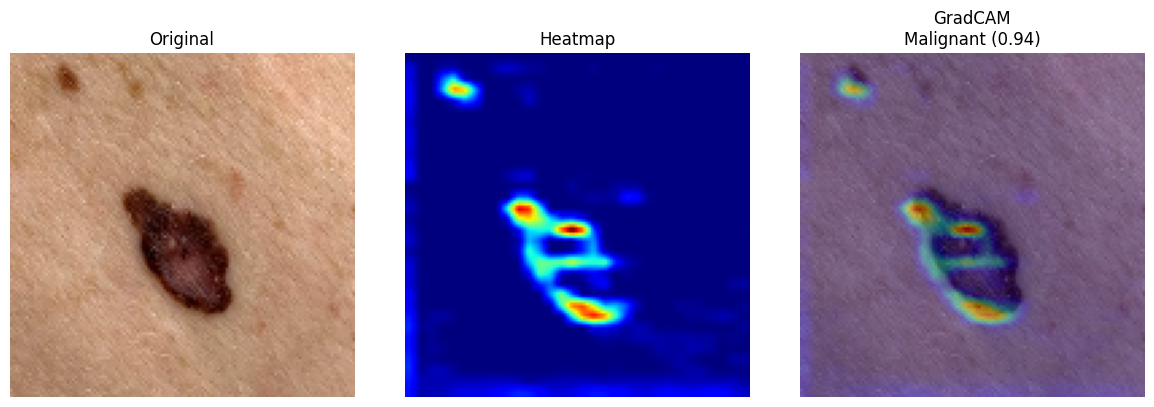

In [112]:
predict_and_gradcam("/kaggle/input/datasets/anikpaul007/new-testing-dataset/cancerornot.jpg")
